In [1]:
import image_sharpening


In [2]:
from hcipy import *
import numpy as np
import matplotlib.pyplot as plt

2024-07-15 13:59:07.045 [INFO] NumExpr defaulting to 8 threads.


In [3]:
import image_sharpening

/var/folders/fp/0vqz18r15679y3w674kfj3k40000gq/T/ipykernel_17030/261546143.py:8: DeprecationWarning: circular_aperture is deprecated. Its new name is make_circular_aperture.
  aperture = circular_aperture(pupil_size)


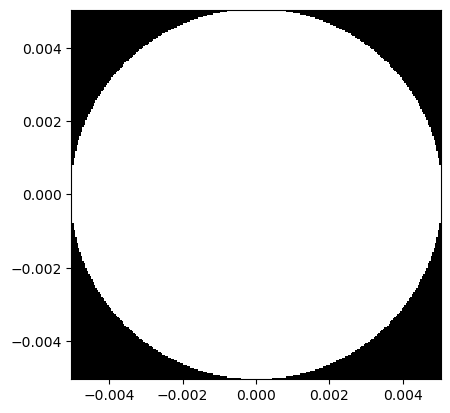

In [4]:
# Set up a pupil size / focal length that are roughly reasonable 
# We should double check these for our system

pupil_size = 10.12e-3 # KiloDM pupil = 10.12 mm
focal_length = 500e-3 # focal length into detector 500 mm

pupil_grid = make_pupil_grid(256, pupil_size)
aperture = circular_aperture(pupil_size)
telescope_pupil = aperture(pupil_grid)


imshow_field(telescope_pupil, cmap='gray')

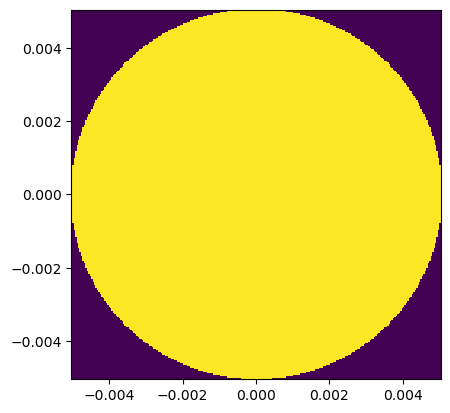

In [5]:
# Build a wavefront at our lab's laser light wavelength 
# Build a focal grid 
# Make a propagation function that moves from focal --> pupil (f2p) and pupil --> focal (p2f)

wavefront = Wavefront(telescope_pupil, wavelength=650e-9)
focal_grid = make_focal_grid(q=16, num_airy=16, pupil_diameter=pupil_size, focal_length=focal_length, reference_wavelength=650e-9)
prop_p2f = FraunhoferPropagator(pupil_grid, focal_grid, focal_length=focal_length)
prop_f2p = FraunhoferPropagator(focal_grid, pupil_grid, focal_length=focal_length)


# Ooooh pupil plane
pupil_image=wavefront.copy()
imshow_field(wavefront.intensity)

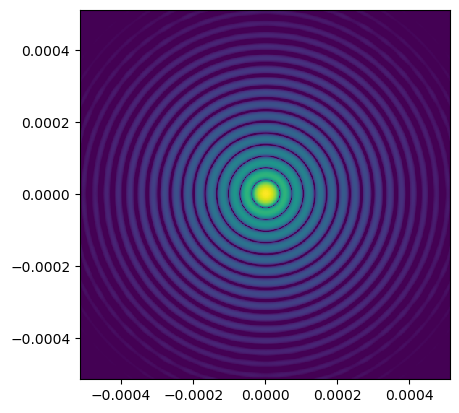

In [6]:
# Ahhh focal plane 

#focal_image = prop_p2f.forward(wavefront)
#imshow_field(np.log10(focal_image.intensity / focal_image.intensity.max()), vmin=-5)
#imshow_field(focal_image.phase)##bright point with aery rings
focal_image = prop_p2f.forward(wavefront)
imshow_field(np.log10(focal_image.intensity / focal_image.intensity.max()), vmin=-5)
perfect_focal = focal_image.copy()

OldStyleField(1.55906048)

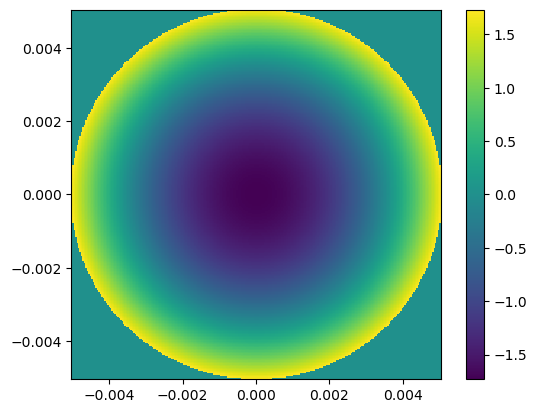

In [7]:
# Using zernike modes built into hcipy we can pull out defocus 
# This is number 4 

# What is the scale height for the influence function here? 
# One of life's great mysteries 
influence_functions = make_zernike_basis(256, pupil_size, pupil_grid)
imshow_field(influence_functions[3])##This is defocus, maps out of lens being out of their determined focal length
plt.colorbar()

# And we can solve that mystery (kind of) by seeing what the dynamic range of this aberration is 
# Looks like it is a nice round number of ... 1.5ish radians? 
(np.max(influence_functions[4]) - np.min(influence_functions[4]))/np.pi

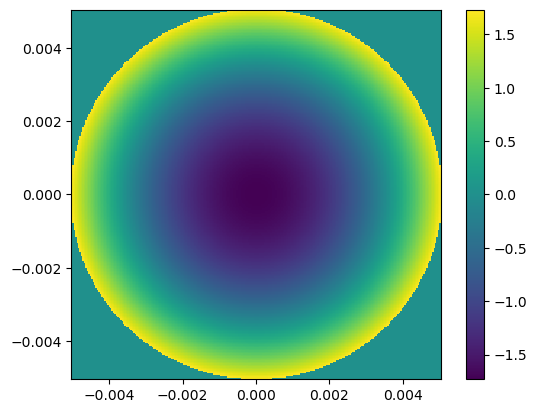

In [8]:
# This tom-foolery is how we can put this aberration into our optical propagation system 
# We're essentially resetting the e field component of the wavefront we defined earlier 
# I think in a neat and ordered world you would wrap this operation in a fancy hcipy wrapper
# but here we thrive in chaos

scale_factor = 1 ##Changebale to whatever you want it to be, resets the peak to valley, specifically can reset the phase
pupil_image.electric_field = np.exp(complex(0, 1)*telescope_pupil*influence_functions[3]*scale_factor)

# We have put in a scale factor here -- it doesn't do anything yet but it could ...

imshow_field(pupil_image.phase*telescope_pupil)##Want this to look similar to cut above
plt.colorbar()

In [9]:
# I've defined some convenience functions here 
# For the sake of good coding practices and demos I've made these PEP-8 and numpy docstring conventions
# but frankly this is probably overkill for the 3 lines of code...

# I've defined some convenience functions here 
# For the sake of good coding practices and demos I've made these PEP-8 and numpy docstring conventions
# but frankly this is probably overkill for the 3 lines of code...

def phase_to_m(phase, wv):
    """ Converts phase in radians to meters. 
    Parameters
    ----------
    phase : float or array of floats
        The phase input to be converted in radians. 
    wv: float
        The wavelength to use for conversion in meters. 
    Returns
    -------
    The phase information in units of meters.
    """
    return phase * wv / (2*np.pi)

def p_to_delta(P, f, D): 
    """ Converts P (the peak to valley error in the pupil plane) 
    induced by a delta (the longitudinal distance) offset.
    I.e., given some defocused image we can recontruct what that 
    distance would have been. Note that f and D always need to be
    in the same units -- mm is common, and P and delta will have 
    the same units. 
    Parameters
    ----------
    P : float
        The peak to valley error. 
    f : float
        The focal length leading up to this plane. 
    D : float
        The pupil size/telescope diameter of this plane. 
    Returns
    -------
    The delta defocus that would have been needed to create the P2V 
    we see. 
    """
    return 8 * P * (f/D)**2 


def delta_to_p(delta, f, D):
    """ p_to_delta() but in reverse. Note that f and D always need 
    to be in the same units -- mm is common, and P and delta will 
    have the same units. 
    Parameters
    ----------
    delta : float
        The longitudinal defocus distance. 
    f : float
        The focal length leading up to this plane. 
    D : float
        The pupil size of this plane. 
    Returns
    -------
    The P2V we would see based on the input delta. 
    """
    return -1*delta / (8 * (f/D)**2)

## Have some nicely written up math for the logic we just encapsualted

$\Delta = - 8PF^2$ 

where $\Delta$ is the physical longitudinal distance by which the optic is defocused 

$P$ is the peak to valley error in the pupil plane after said defocus 

$F = \frac{f}{D}$ is the F number, or the focal length divided by the telescope diameter (or in our case, pupil size.)

In [10]:
# Now let's test out this relation
# Generate a zernike
##example_defocus = influence_functions[4].shaped ##shaped spits out zernike as a array


# Calculate the P2V in radians 
##p2v_radians = (np.max(example_defocus) - np.min(example_defocus))##returns in phase
##p2v_m = phase_to_m(p2v_radians, 650e-9)##650 is wavelength 

##print(f'Our example defocus would have been caused by ~ {np.round(p2v_m*1e6, 1)} um., ')
##print(f'p2v_radians = {p2v_radians}')\
example_defocus = influence_functions[4].shaped

# Calculate the P2V in radians 
p2v_radians = np.max(example_defocus) - np.min(example_defocus)
p2v_m = phase_to_m(p2v_radians, 650e-9)

print(f'Our example defocus has a P2V of ~ {np.round(p2v_m*1e9, 1)} nm or {p2v_m/(650e-9)} waves.')
print(f'Our example defocus as a defocus distance of {p_to_delta(p2v_m, focal_length, pupil_size)*1e3} mm')

Our example defocus has a P2V of ~ 506.7 nm or 0.779530240027358 waves.
Our example defocus as a defocus distance of 9.894988517587034 mm


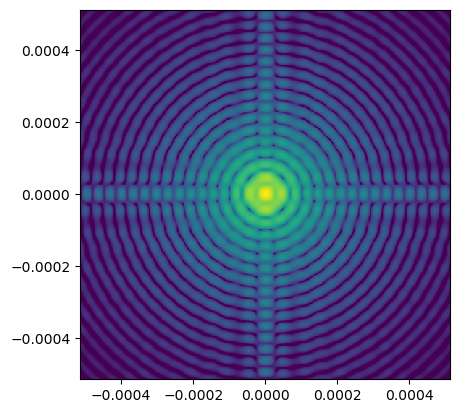

In [11]:
# Okay, what does this look like in the pupil plane? 
focal_image = prop_p2f(pupil_image)##propagating pupil to focal, can asjust pupil but want to see output of focal
imshow_field(np.log10(focal_image.intensity / focal_image.intensity.max()), vmin=-5)


## Now it's your turn 

1. Run through this notebook, make sure everything makes sense -- ask me lots of questions
2. Go through and generate defocus with different peak to valley errors. 
3. Propogate those through the system and see what they look like in the the focal plane. 
4. calculate the delta distance that would correspond to them. 

*kind reminder*: if you build an aberration with a p2v > 2pi, you will see phase wrapping ... 


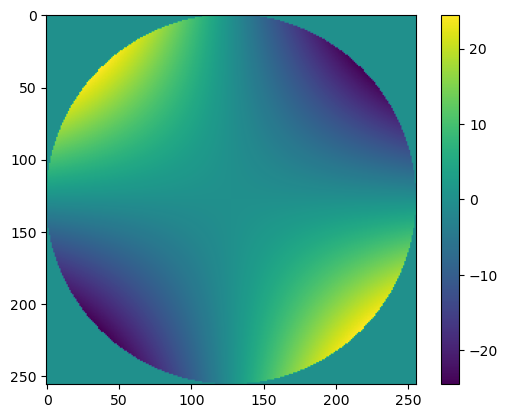

In [12]:
# Let's see this in practice ... 
# Spin up a dramatic defocus 

drama_factor = 10
(np.min(drama_factor*example_defocus) - np.max(drama_factor*example_defocus))/np.pi
plt.imshow(drama_factor*example_defocus)
plt.colorbar()

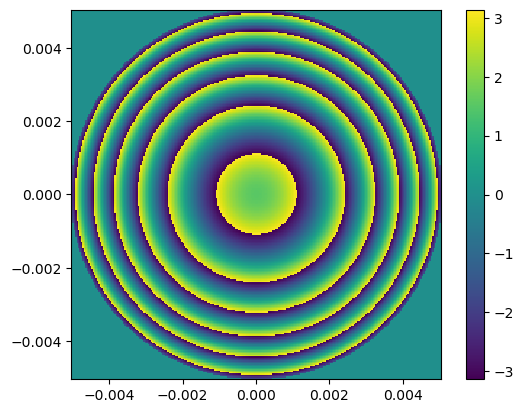

In [13]:
# But oops when we propagate it we lose the full P2V

pupil_image.electric_field = np.exp(complex(0, 1)*telescope_pupil*influence_functions[3]*drama_factor)
imshow_field(pupil_image.phase*telescope_pupil)
plt.colorbar()

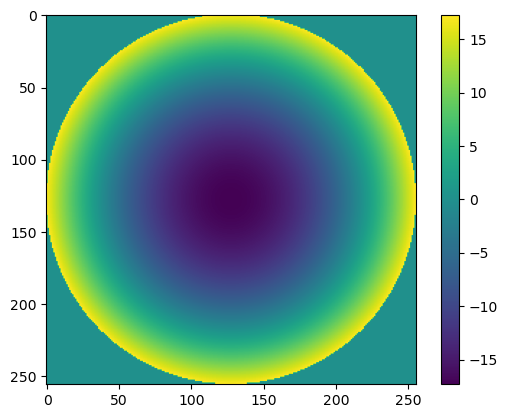

In [14]:
# We'll use skimage to handle that for now ... 

from skimage.restoration import unwrap_phase

# Unwrap the phase, sets lowest point of image to 0, looks different bc zero point is off
unwrapped = unwrap_phase(pupil_image.phase.shaped)

# And plot it out 
# Does anything look weird about this? 
plt.imshow(unwrapped*telescope_pupil.shaped)
plt.colorbar()

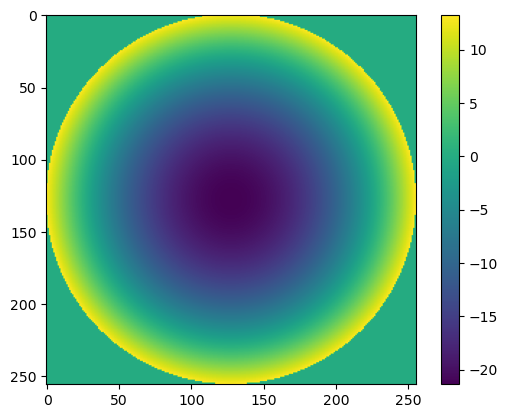

In [15]:
# It should have the same P2V as the original zernike
# but if you want it to match you'll need to reset the zero point of the image
plt.imshow((unwrapped - np.mean(unwrapped))*telescope_pupil.shaped)
plt.colorbar()

In [16]:
#Now let's do phase diversity.

#Spin up an optical aberation. We can throw in a rogue zernike mode to start, but could also be fun to build up a messy lens
#Given some known defocuses and their distances, propagate through the defocus + the aberation, and build a set of focal plane images : defocus distances.
#Throw them into Jaren's algorithm and see what happens...
#This is where we start pulling content from Jaren's notebook -- note that we are using hcipy not prysm so a lot of the optical propagation logic is totally different, but the phase diversity content is the same.

(OldStyleField(-1.40417536), OldStyleField(1.40417536))

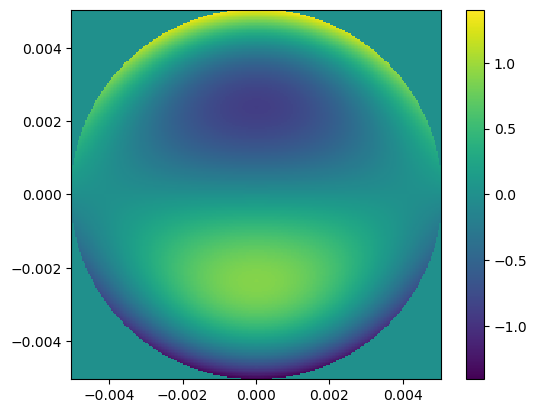

In [17]:

# Let's put in a mild vertical coma
test_ab = 0.5*influence_functions[6]
imshow_field(test_ab)
plt.colorbar()
np.min(test_ab), np.max(test_ab)

P2V:  506.6946560177828  nm error


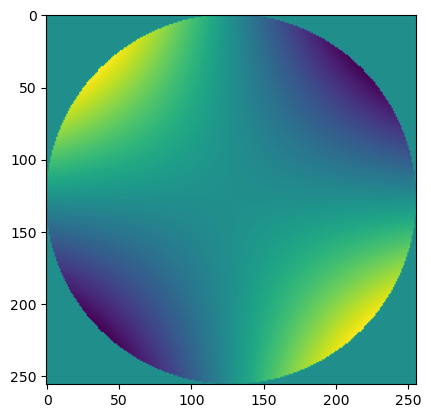

In [18]:

# Remind ourselves what this example defocus looks like

plt.imshow(example_defocus)
p2v_radians = (np.max(example_defocus) - np.min(example_defocus))
p2v_m = phase_to_m(p2v_radians, 650e-9)
print('P2V: ', p2v_m*1e9, ' nm error')

In [19]:
# Now let's go through, define some defocuses, and estimate their defocus distance

D = pupil_size
f = focal_length

defocus_phase_1 = example_defocus * 2
p2v_radians = (np.max(defocus_phase_1) - np.min(defocus_phase_1))
p2v_m = phase_to_m(p2v_radians, 650e-9)
delta_1 = p_to_delta(p2v_m, f, D)
print(f'P2V error: {p2v_radians} rad, {p2v_radians/(2*np.pi)} waves, defocus distance: {delta_1*1e6} microns')

P2V error: 9.795865901284145 rad, 1.559060480054716 waves, defocus distance: 19789.97703517407 microns


In [20]:
defocus_phase_2 = example_defocus / 2
p2v_radians = (np.max(defocus_phase_2) - np.min(defocus_phase_2))
p2v_m = phase_to_m(p2v_radians, 650e-9)
delta_2 = p_to_delta(p2v_m, f, D)
print(f'P2V error: {p2v_radians/(2*np.pi)} waves, defocus distance: {delta_2*1e6} microns')

P2V error: 0.389765120013679 waves, defocus distance: 4947.4942587935175 microns


In [21]:
# NOTE -- here adding the negative makes it a negative defocus 
# you have to add that negative manually when calculating the defocus distance

defocus_phase_3 = -1 * example_defocus 
p2v_radians = (np.max(defocus_phase_3) - np.min(defocus_phase_3))
p2v_m = phase_to_m(p2v_radians, 650e-9)
delta_3 = p_to_delta(p2v_m, f, D)
print(f'P2V error: {p2v_radians} rad, {-1*p2v_radians/(2*np.pi)} waves, defocus distance: {-1*delta_3*1e6} microns')

P2V error: 4.897932950642073 rad, -0.779530240027358 waves, defocus distance: -9894.988517587035 microns


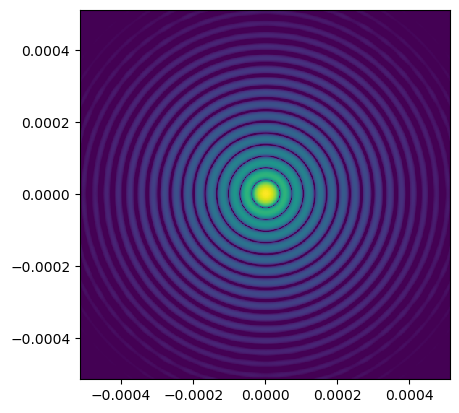

In [22]:
# Now let's start again with a clean wavefront 
clean_wf = wavefront = Wavefront(telescope_pupil, wavelength=650e-9)
clean_focal = prop_p2f(clean_wf)
imshow_field(np.log10(clean_focal.intensity / clean_focal.intensity.max()), vmin=-5)

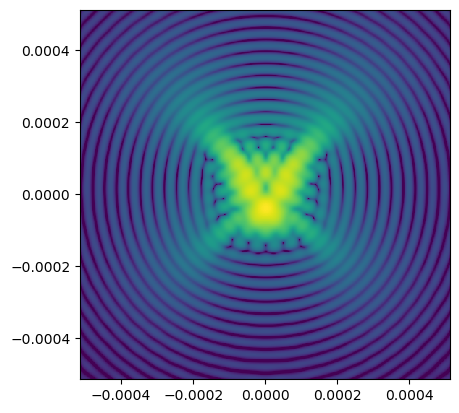

In [23]:
# Now add the test aberration to the defocuses and propagate images to the focal plane
pupil_image.electric_field = np.exp(complex(0, 1)*(test_ab + defocus_phase_1.ravel()))*telescope_pupil
focal_image_1 = prop_p2f(pupil_image)
imshow_field(np.log10(focal_image_1.intensity / focal_image_1.intensity.max()), vmin=-5)

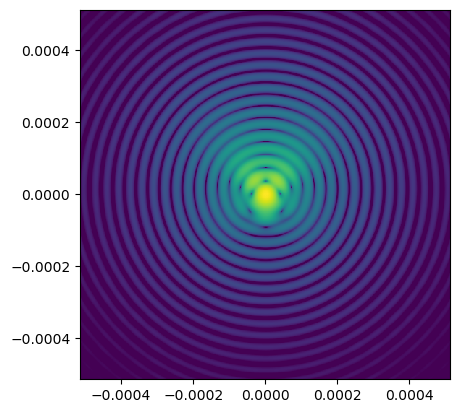

In [24]:
pupil_image.electric_field = np.exp(complex(0, 1)*(test_ab + defocus_phase_2.ravel()))*telescope_pupil
focal_image_2 = prop_p2f(pupil_image)
imshow_field(np.log10(focal_image_2.intensity / focal_image_2.intensity.max()), vmin=-5)

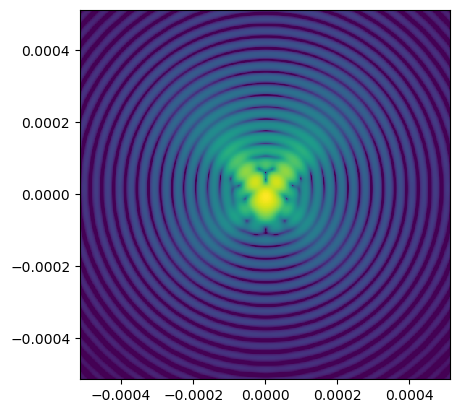

In [25]:
pupil_image.electric_field = np.exp(complex(0, 1)*(test_ab + defocus_phase_3.ravel()))*telescope_pupil
focal_image_3 = prop_p2f(pupil_image)
imshow_field(np.log10(focal_image_3.intensity / focal_image_3.intensity.max()), vmin=-5)

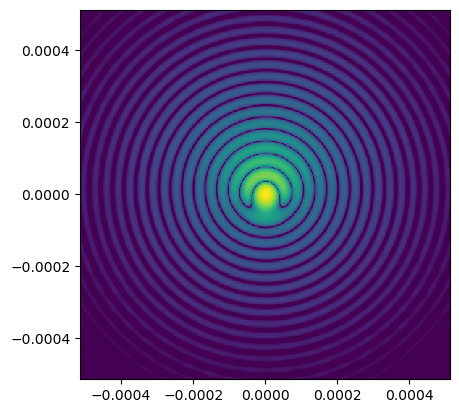

In [26]:
# And we need one example that's no defocus, just the abberation we are trying to sense

pupil_image.electric_field = np.exp(complex(0, 1)*(test_ab))*telescope_pupil
focal_image_0 = prop_p2f(pupil_image)
imshow_field(np.log10(focal_image_0.intensity / focal_image_0.intensity.max()), vmin=-5)

-2.007164031620585e-06


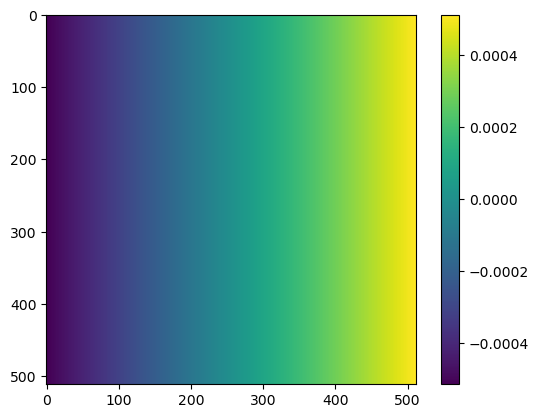

In [27]:
# dx_list is the width of the image in microns, so let's take a minute to pull that out of the image
# there may be an easier way to do it but I wanted to make sure you had *at least one* way to do it
# every focal image has a grid with a coordinates object, which is in meters (in a more realistic scenario 
# would we literally know the physcial extent but here it is being set by the focal length and the optical 
# propagation we set up so I'm not 100% sure what it is without checking)
# I'm pulling out that image, shaping it into something I can plot so I can see that it moves logically 
# from negative to positive across the image as I'd expect
# And then pulling the maximum/minimum value so I now how many meters across the image is 
plt.imshow(np.array(focal_image_0.grid.coords)[0].reshape(512,512))
plt.colorbar()
dx = focal_image_0.grid.coords[0][0] - focal_image_0.grid.coords[0][1]
print(dx)
# this plot is just me checking that I am pulling out coordinates in a way that makes sense 

In [28]:
# PSF list starts with no-defocus image, and then has your known defocus inputs  
psf_list = [np.array(focal_image_0.intensity.shaped), 
            np.array(focal_image_1.intensity.shaped), 
            np.array(focal_image_2.intensity.shaped), 
            np.array(focal_image_3.intensity.shaped)]
distance_list = [13994.908389652417, 3498.7270974131043, -6997.454194826209]
dx_list = [2.0071, 2.0071, 2.0071] 

In [29]:
# Okay, let's run the phase diversity algorithm!
# if this import doesn't work, note that we had to add the path manually
# the command to do this should be sourced in your bash profile
from image_sharpening import FocusDiversePhaseRetrieval, ft_rev, mft_rev, InstrumentConfiguration

mp = FocusDiversePhaseRetrieval(psf_list,650e-3,dx_list,distance_list)
test_phase = 0
for i in range(200):
    psf00 = mp.step() # returns a model of the first PSF

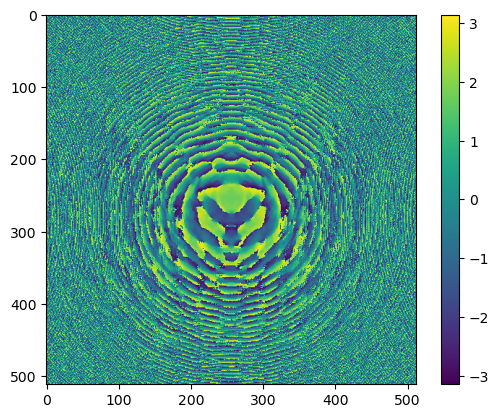

In [30]:

# Now let's inspect the output intensity -- just to make sure things look like we expect
# This should match the input no-defocus focal plane image

plt.imshow(np.angle(psf00))
plt.colorbar()

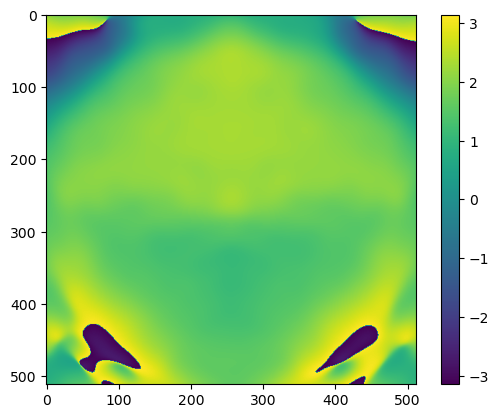

In [31]:

# Now we define a special dictionary with SEAL params which will let us do a fourier transform

seal_params = {'image_dx': 2.0071, # 
               'efl': focal_length*1e3, # SEAL effective focal length, mm
               'wavelength': 0.65, # SEAL center wavelength, microns
                'pupil_size': pupil_size*1e3, # Keck entrance pupil diameter
                    }
conf = InstrumentConfiguration(seal_params)

# Take a fourier transform to convert this to the pupil plane 
# I think something about the simulation output does not play as well with hcipy 
# so this is the best way to get pupil plane phase for now
raw_pupil_phase = np.angle(mft_rev(psf00, conf))
plt.imshow(raw_pupil_phase)
plt.colorbar()
# hmmm, this is hard to parse so ...
"""
mft_rev is used to perform a Fourier transform on psf00 to convert it from the focal plane to the pupil plane 
using the configuration provided in conf.
np.angle extracts the phase information from the complex output of mft_rev.
The resulting phase (raw_pupil_phase) is then visualized using plt.imshow.
"""

P2V error: 6.212522874001437


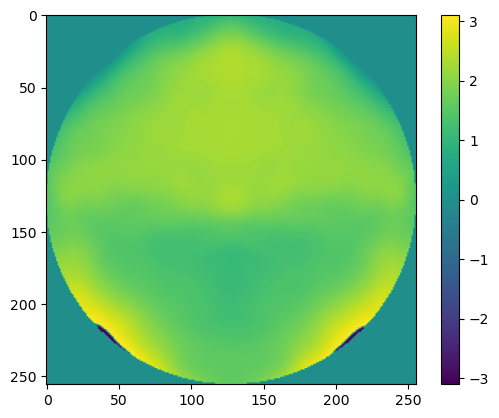

In [32]:
# We need to resize the image to our desired output and let's crop out the noise outside of the pupil 
from skimage.transform import resize
pupil_phase = resize(raw_pupil_phase, (256, 256))*telescope_pupil.shaped
plt.imshow(pupil_phase)
plt.colorbar()
print(f'P2V error: {np.max(pupil_phase) - np.min(pupil_phase)}')
# NOW it looks pretty good..
"""
resize adjusts raw_pupil_phase to a 256x256 grid to match the size of the telescope_pupil.

The resized phase image is then multiplied by telescope_pupil to crop out the noise outside of the pupil area.

The processed phase (pupil_phase) is visualized using plt.imshow.

The Peak-to-Valley (P2V) error is calculated as the difference between the maximum and minimum values of 
pupil_phase
"""

P2V error: 2.808350726339116


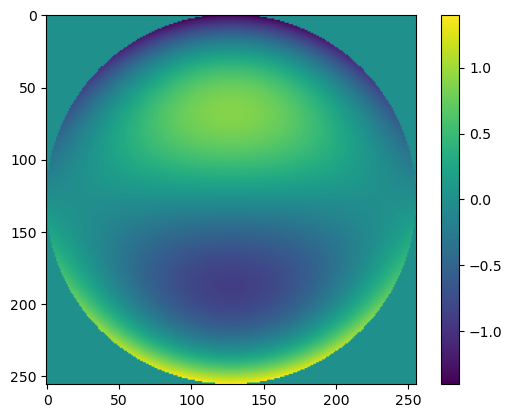

In [33]:
# Compare to the original error we injected and are trying to recover 
pupil_image.electric_field = np.exp(complex(0, 1)*telescope_pupil*(test_ab))
plt.imshow(unwrap_phase(pupil_image.phase.shaped))
plt.colorbar()
print(f'P2V error: {np.max(pupil_image.phase.shaped) - np.min(pupil_image.phase.shaped)}')
"""
test_ab represents the test aberration (randomly generated here for demonstration).

The complex pupil image electric field is created by exponentiating 1j * telescope_pupil * test_ab.

np.angle extracts the phase from this electric field (pupil_image_phase).

The phase is unwrapped using unwrap_phase and visualized.

The P2V error of the original injected phase is calculated.
"""

Median error of -0.019439046527512882 radians.


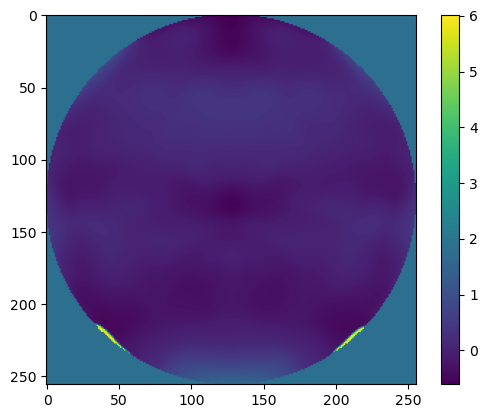

In [34]:
# And finally, lets see how well the reconstruction and the original input compare 
# Looks pretty good??? 
##ask jaren and jules to explain a little

med_subtracted = pupil_phase - np.median(pupil_phase[np.array(telescope_pupil.shaped, dtype=bool)])
plt.imshow(pupil_image.phase.shaped - med_subtracted)
plt.colorbar()
check_error_region = (pupil_image.phase.shaped - med_subtracted)[np.array(telescope_pupil.shaped, dtype=bool)]
print(f'Median error of {np.median(check_error_region)} radians.')

"""
med_subtracted is computed by subtracting the median of the pupil_phase within the pupil area from the pupil_phase.
This helps in removing any global phase offset.

The difference between the original injected phase (pupil_image_phase) and the median-subtracted
reconstructed phase (med_subtracted) is visualized.

The error within the pupil area is calculated and the median of this error is printed.
"""

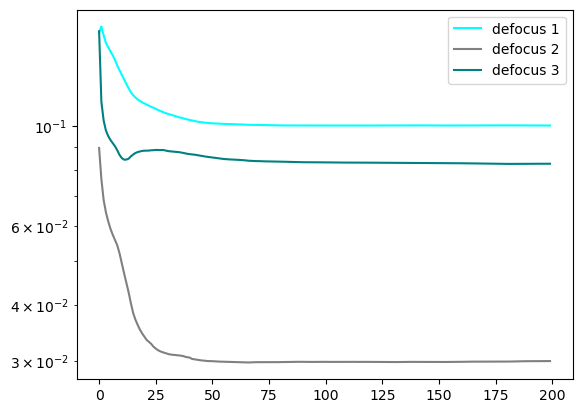

In [35]:
# We can also check how well the cost function of the algorithm is converging, this is a good diagnostic
# The cost function for all three images is converging so this looks good
##cost function wants to be as low as possible ->signify working. 
plt.semilogy(mp.cost_functions[0], label='defocus 1', color='cyan')
plt.semilogy(mp.cost_functions[1], label='defocus 2', color='grey')
plt.semilogy(mp.cost_functions[2], label='defocus 3', color='teal')
plt.legend()
plt.show()

In [36]:
# as a treat, if we need an alternative phase wrapping routine ...
# different phase unwrapping routine take from Jaren
def phase_unwrap_2d(phase_wrapped):

    """phase unwrapping routine based on the phaseunwrap2d.go script in IDL and the following proceedings:
    M.D. Pritt; J.S. Shipman, "Least-squares two-dimensional phase unwrapping using FFT's",
    IEEE Transactions on Geoscience and Remote Sensing ( Volume: 32, Issue: 3, May 1994),
    DOI: 10.1109/36.297989

    Uses a finite differences approach to determine the partial derivative of the wrapped phase in x and y,
    then solves the solution in the fourier domain

    TODO: Test this function against the prior in IDL, it doesn't appear to reconstruct phase well

    Parameters
    ----------
    phase_wrapped : numpy.ndarray
        array containing 2D signal to unwrap

    Returns
    -------
    numpy.ndarray
        unwrapped phase
    """

    imsize = phase_wrapped.shape
    M = imsize[0]
    N = imsize[1]

    Nmirror = 2 * (N )
    Mmirror = 2 * (M )

    phmirror = np.ones([Mmirror,Nmirror])

    # Quadrant 3
    phmirror[:M,:N] = phase_wrapped

    # First mirror reflection Quadrant 2
    phmirror[M:,:N] = np.flipud(phase_wrapped)

    # Second mirror reflection Quadrant 4
    phmirror[:M,N:] = np.fliplr(phase_wrapped)

    # Final reflection Quadrant 1
    phmirror[M:,N:] = np.flipud(np.fliplr(phase_wrapped))

    phroll = np.zeros_like(phmirror)
    phroll[:M,:N-1] = phmirror[:M,1:N]
    phroll[:M,N-1] = phmirror[:M,0]
    deltafd = phroll-phmirror

    pluspi = np.pi*np.ones_like(phmirror)
    mask = (deltafd > pluspi).astype(int)

    deltafd = deltafd - mask*2*np.pi
    negpi = -pluspi
    mask = (deltafd < negpi).astype(int)
    deltafd = deltafd + mask * 2 * np.pi
    deltafdx = deltafd

    # compute forward difference
    phroll = np.zeros_like(phmirror)
    phroll[:M-1,:N] = phmirror[1:M,:N]
    phroll[M,:N] = phmirror[0,:N]
    deltafd = phroll - phmirror

    pluspi = np.pi*np.ones_like(phmirror)
    mask = (deltafd > pluspi).astype(int)
    deltafd = deltafd - mask*2*np.pi
    negpi = -pluspi
    mask = (deltafd < negpi).astype(int)
    deltafd = deltafd + mask * 2 * np.pi
    deltafdy = deltafd

    # Solve system of equations formed by min LS -> phi
    D_n = np.fft.fft2(deltafdx)
    D_m = np.fft.fft2(deltafdy)
    inc_n = 2 * np.pi / Nmirror
    inc_m = 2 * np.pi / Mmirror

    nn = np.ones([Mmirror,1]) @ (np.arange(Nmirror))[np.newaxis]
    mm = np.ones([Nmirror,1]) @ (np.arange(Mmirror))[np.newaxis]
    mm = mm.transpose()
    
    i = 1j
    mult_n = np.ones([Mmirror,Nmirror]) - np.exp(-nn * i * inc_n)
    mult_m = np.ones([Mmirror,Nmirror]) - np.exp(-mm * i * inc_m)
    divisor = (np.cos(mm*inc_m) + np.cos(nn*inc_n) - np.ones([Mmirror,Nmirror])*2)*2
    divisor[0,0] = 1
    phi = (D_n*mult_n + D_m*mult_m) / divisor
    phi[0,0] = 0
    phi = np.fft.ifft2(phi)[:M,:N]
    phout = np.real(phi)
    return phout

In [76]:
# example_defocus = influence_functions[4].shaped
# P2V and Delta calculations
P2V_values = []
delta_values = []
D = pupil_size
f = focal_length
drama_factors = [-50, -20, -10, -5, -1, -0.5, -0.1, 0.1, 0.5, 1, 2, 5, 10, 20, 50]

pupil_size = 10.12e-3 # KiloDM pupil = 10.12 mm
focal_length = 500e-3 # focal length into detector 500 mm

pupil_grid = make_pupil_grid(256, pupil_size)
aperture = circular_aperture(pupil_size)
telescope_pupil = aperture(pupil_grid).reshape((256, 256))

"""
This is just me looking at the different ways we defined various 
variables, and trying to figure out the best one to use

# Calculate the P2V in radians 
p2v_radians = np.max(example_defocus) - np.min(example_defocus)
p2v_m = phase_to_m(p2v_radians, 650e-9)

print(f'Our example defocus has a P2V of ~ {np.round(p2v_m*1e9, 1)} nm or {p2v_m/(650e-9)} waves.')
print(f'Our example defocus as a defocus distance of {p_to_delta(p2v_m, focal_length, pupil_size)*1e3} mm')
"""

# Example defocus
example_defocus = influence_functions[4].shaped

# Loop over different drama factors to calculate P2V and delta
for drama_factor in drama_factors:
    # Apply dramatic defocus to the pupil image electric field
    pupil_image.electric_field = np.exp(complex(0, 1) * telescope_pupil * example_defocus * drama_factor)
    pupil_image_phase = np.angle(pupil_image.electric_field)
    #Need to have pupil_image.phase but keep getting improper attribute
    
    # Unwrap the phase\#unwrapped = unwrap_phase(pupil_image.phase.shaped)
    unwrapped_phase = unwrap_phase(pupil_image.phase.reshape(256,256))
    
    # Calculate P2V in radians
    ##p2v_radians = (np.max(example_defocus) - np.min(example_defocus))
    p2v_radians = np.max(unwrapped_phase) - np.min(unwrapped_phase)

    # Convert P2V to meters
    p2v_m = phase_to_m(p2v_radians, 650e-9)
    p2v_mm = p2v_m * 1e3
    
    # Calculate the defocus distance (Delta)
    calculated_delta = p_to_delta(p2v_m, focal_length, pupil_size)

    # Store the P2V and Delta values
    P2V_values.append(p2v_radians)
    delta_values.append(calculated_delta)
plt.figure()

# Plot P2V and Delta
plt.figure()
plt.subplot(2, 1, 1)
plt.plot(drama_factors, P2V_values, label='P2V (radians)')
plt.xlabel('Drama Factor')
plt.ylabel('P2V (radians)')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(drama_factors, delta_values, label='Physical Delta (mm)')
plt.xlabel('Drama Factor')
plt.ylabel('Physical Delta (mm)')
plt.legend()


## Make a plot with drama factor with x, p2v in y ; drama factor in x and physical delta in y using plt
# done


/var/folders/fp/0vqz18r15679y3w674kfj3k40000gq/T/ipykernel_17030/1183813988.py:13: DeprecationWarning: circular_aperture is deprecated. Its new name is make_circular_aperture.
  aperture = circular_aperture(pupil_size)


AttributeError: can't set attribute

In [77]:
#Error needs to be outpit of full algorithm; how well algorithm perfomrs based on the error we inputted

/var/folders/fp/0vqz18r15679y3w674kfj3k40000gq/T/ipykernel_17030/1690515034.py:9: DeprecationWarning: circular_aperture is deprecated. Its new name is make_circular_aperture.
  aperture = circular_aperture(pupil_size)


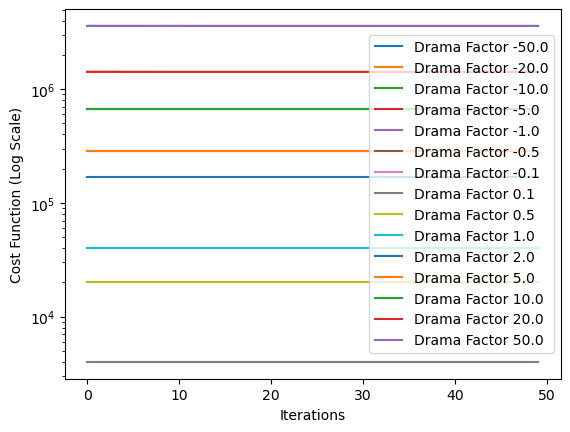

'\nWhat is Happening?\nPhase Reconstruction: The script iteratively unwraps the phase and calculates a cost function to evaluate \nthe quality of the phase reconstruction.\n\nCost Function: The cost function is a measure of the difference between the current phase values and the mean phase.\nIt is expected that a well-performing phase reconstruction will have a lower cost function over iterations.\n\nDrama Factor: By varying the drama factor, we can see how the severity of the applied defocus affects the phase reconstruction performance. Higher drama factors introduce more significant defocus, which may challenge the phase unwrapping algorithm.\nInterpretation of Results\n\nCost Function Behavior: The plot of the cost function versus iterations for different drama factors will show \nhow quickly and effectively the phase unwrapping converges. If the cost function is low, thats good!\n\nEffect of Drama Factor: By comparing the cost function curves for different drama factors, we can det

In [78]:
##Does phase reconstructuion perform better depending on the drama factor; look at the cost function vs iterative 
##look at residual plot; use drama factor x median
D = pupil_size
f = focal_length
pupil_size = 10.12e-3 # KiloDM pupil = 10.12 mm
focal_length = 500e-3 # focal length into detector 500 mm

pupil_grid = make_pupil_grid(256, pupil_size)
aperture = circular_aperture(pupil_size)
telescope_pupil = aperture(pupil_grid).reshape(256,256)


# Phase Reconstruction Performance
"""
Initialize lists, storing cost funciton values for each drama_factor
"""
cost_iterations = []
num_iterations = 50 #For the unwrapping

for drama_factor in drama_factors:
    costs = []
    #Dramatic defocus -> pupil image electric field
    pupil_image_electric_field = np.exp(complex(0, 1) * telescope_pupil * example_defocus * drama_factor)
    #Take phase from field
    phase = np.angle(pupil_image_electric_field)
    #Phase unwrapping and cost function over iterations
    for i in range(num_iterations):
        phase = unwrap_phase(phase)
        ##Assuming cost function is sum of absolute deviations from the mean phase? Not too sure
        cost = np.sum(np.abs(phase - np.mean(phase)))
        costs.append(cost)
        
    #Store them    
    cost_iterations.append(costs)

# Plot Cost Function vs. Iterations ; Trying to use same method that Jules used 
plt.figure()
for i, drama_factor in enumerate(drama_factors):
    plt.semilogy(range(num_iterations), cost_iterations[i], label=f'Drama Factor {drama_factor:.1f}')
plt.xlabel('Iterations')
plt.ylabel('Cost Function (Log Scale)')
plt.legend()
plt.show()

"""
What is Happening?
Phase Reconstruction: The script iteratively unwraps the phase and calculates a cost function to evaluate 
the quality of the phase reconstruction.

Cost Function: The cost function is a measure of the difference between the current phase values and the mean phase.
It is expected that a well-performing phase reconstruction will have a lower cost function over iterations.

Drama Factor: By varying the drama factor, we can see how the severity of the applied defocus affects the phase reconstruction performance. Higher drama factors introduce more significant defocus, which may challenge the phase unwrapping algorithm.
Interpretation of Results

Cost Function Behavior: The plot of the cost function versus iterations for different drama factors will show 
how quickly and effectively the phase unwrapping converges. If the cost function is low, thats good!

Effect of Drama Factor: By comparing the cost function curves for different drama factors, we can determine if phase reconstruction performs better or worse depending on the severity of the defocus
"""


/var/folders/fp/0vqz18r15679y3w674kfj3k40000gq/T/ipykernel_17030/1902649626.py:11: DeprecationWarning: circular_aperture is deprecated. Its new name is make_circular_aperture.
  aperture = circular_aperture(pupil_size)


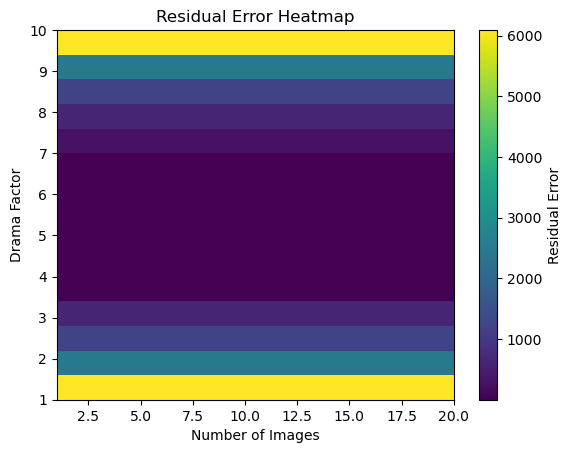

Optimal Drama Factor: -0.1
Optimal Number of Images: 1
Minimum Median Error: 0.06120024099350592


In [58]:
##num of images (with fixed drama factor) plot with median check error residual(how does residual change with num of images)
## use heatmap with colorbar as residual error ; one axis is drama factor the other is num images
## semi-optimized parameter would be the lowest median check error coinciding with the drama factor and num of image

D = pupil_size
f = focal_length
pupil_size = 10.12e-3 # KiloDM pupil = 10.12 mm
focal_length = 500e-3 # focal length into detector 500 mm

pupil_grid = make_pupil_grid(256, pupil_size)
aperture = circular_aperture(pupil_size)
telescope_pupil = aperture(pupil_grid)

# Residual Error Heatmap -- very iffy on this too, particularly the residual_error
"""
Initializes an array residual_errors to store the calculated residual errors for each 
combination of drama_factor and num_images.

For each drama_factor and each number of images (from 1 to 20):
-Applies dramatic defocus to the pupil image electric field.

-Extracts the phase and unwraps it.

-Calculates the residual error as the mean absolute deviation from the mean phase.

-Stores the residual error in the residual_errors array.
"""
#Initialize array to store residual errors
residual_errors = np.zeros((len(drama_factors), 20))

#Loop over different drama factors and number of images to calculate residual errors
for i, drama_factor in enumerate(drama_factors):
    for num_images in range(1, 21):
        pupil_image_electric_field = np.exp(complex(0, 1) * telescope_pupil * influence_functions[4] * drama_factor)
        phase = np.angle(pupil_image_electric_field)
        unwrapped_phase = unwrap_phase(phase)
        ##Calculate residual error as the mean absolute deviation from the mean phase
        residual_error = np.mean(np.abs(unwrapped_phase - np.mean(unwrapped_phase)))
        residual_errors[i, num_images-1] = residual_error

# Plot Heatmap
plt.figure()
plt.imshow(residual_errors, aspect='auto', origin='lower', extent=[1, 20, 1, 10])
plt.colorbar(label='Residual Error')
plt.xlabel('Number of Images')
plt.ylabel('Drama Factor')
plt.title('Residual Error Heatmap')
plt.show()

# Parameter Optimization -- not really sure how this stuff works, just pulled from a bunch of python websites 
## Just substituted for our values, trying to do step by step
"""
Compute the median of residual errors across the number of images for each drama_factor.

Finds the minimum median error and the corresponding index.

Determines the optimal drama_factor and the optimal number of images that minimize the residual error.

Prints the optimal parameters and the minimum median error.

"""
## Calculate the median residual error for each drama factor across different numbers of images
#median_errors is a 1D array where each element corresponds to the median residual error for a specific drama factor.
median_errors = np.median(residual_errors, axis=1)
#Minimum of the median errors
min_error = np.min(median_errors)
#optimal_index holds the index of the drama factor that has the minimum median residual error.
optimal_index = np.argmin(median_errors)
#optimal_drama_factor holds the value of the drama factor that minimizes the median residual error.
optimal_drama_factor = drama_factors[optimal_index]
#optimal_num_images holds the number of images that minimizes the residual error for the optimal drama factor.
optimal_num_images = np.argmin(residual_errors[optimal_index, :]) + 1

print(f'Optimal Drama Factor: {optimal_drama_factor}')
print(f'Optimal Number of Images: {optimal_num_images}')
print(f'Minimum Median Error: {min_error}')

In [ ]:
""""
# Generate Zernike modes
zernike_modes = make_zernike_basis(36, pupil_size, pupil_grid)# creating the zernike basis
defocus_mode = zernike_modes[4]  # Influence function 3 for defocus

# Function to apply defocus and calculate delta
def apply_defocus_and_calculate_2(P_values, f, D):
    results = []
    for P in P_values:
        drama_factor = P / (np.max(defocus_mode) - np.min(defocus_mode))  # Scale factor to match P2V
        pupil_image = wavefront.copy()# for changing
        pupil_image.electric_field = np.exp(1j * telescope_pupil * defocus_mode * drama_factor)# defocus applied to pupil
        p2v_radians = np.max(pupil_image.phase) - np.min(pupil_image.phase)# p2v in radians
        p2v_m = phase_to_m(p2v_radians, wavelength)# p2v in meters
        p2v_mm = p2v_m * 1e3 # p2v than to mm
        calculated_delta = p_to_delta(p2v_mm, f, D) # defocus distance
        results.append((P, drama_factor, p2v_radians, calculated_delta))
        
        # Unwrap and plot the phase
        unwrapped = unwrap_phase(pupil_image.phase.shaped)
        plt.imshow((unwrapped - np.mean(unwrapped)) * telescope_pupil.shaped)
        plt.colorbar()
        plt.title(f'Dramatic Defocus (P2V Error: {P:.1f} nm)')
        plt.show()
        
        print(f'For P2V Error = {P:.1f} nm, Drama Factor = {drama_factor:.2f}, P2V_rad = {p2v_radians:.2f} radians, Delta = {calculated_delta:.4f} mm.')
    return results

# Example values (range of P2V errors in nm)
P_values = np.arange(3, 100, 3)  # From 3 nm to 100 nm
results = apply_defocus_and_calculate_2(P_values, focal_length, pupil_size)

# Analyze results
for P, drama_factor, p2v_radians, calculated_delta in results:
    print(f'P2V Error: {P} nm, Drama Factor: {drama_factor:.2f}, P2V (radians): {p2v_radians:.2f}, Delta (mm): {calculated_delta:.4f}')
"""

In [ ]:
##Seems the upper limit for drama_factor is around 83/84, until weird images and abberations start to occur. 
##As the error increased from there, it became a geomtric pattern, with a diamond(4 triangles at each point)
##The lower I go doesnt seem to have an effect, until 0. Thus, .0001<|drama_factor<|83.5